## Feature Engineering stage

In [18]:
#Importing libraries
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler

import scipy.sparse as sp
import pickle

In [19]:
#Load dataset
df = pd.read_csv("yelp_reviews_clean.csv")

df.head()

,business_id,review_text,rating,review_length,clean_review
0,fqyJZMsKG-oWSGdZIftQgQ,I absolutely loved coming here until today. I ...,2,88,absolutely loved coming today even received ex...
1,ozOneB4jXOD6hv5WBGj4KQ,Exceeded our expectations in every way. Go ear...,5,12,exceeded expectation every way go early parkin...
2,BWkiW0r0h7ytdbWMhay7wA,I came here recently after a big group event. ...,4,238,came recently big group event told coming told...
3,Og4z8nB4ZMZs3oHkVhB_pA,I went to get my hair cut and colored at Bobby...,5,59,went get hair cut colored bobby mack last nigh...
4,I1H5s9cVCGh1nH-4bhsSDA,My review shall be fair and balanced. Not in ...,5,548,review shall fair balanced fox news kind way r...


In [20]:
df.shape


(20000, 5)

In [21]:
df.columns

Index(['business_id', 'review_text', 'rating', 'review_length',
       'clean_review'],
      dtype='object')

In [22]:
#TF-IDF Feature extraction

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    stop_words='english'
)

X_text = tfidf.fit_transform(df['clean_review'])

print("TF-IDF feature matrix shape:", X_text.shape)

TF-IDF feature matrix shape: (20000, 5000)


In [23]:
#Selecting Numerical Features
X_length = df['review_length'].values.reshape(-1,1)
X_rating = df['rating'].values.reshape(-1,1)

In [24]:
X = sp.hstack([X_text, X_length, X_rating])

print("Final feature matrix shape:", X.shape)

Final feature matrix shape: (20000, 5002)


## Making the Isolation Forest Model

In [25]:
iso_model = IsolationForest(
    n_estimators=100,       #Number of trees
    contamination=0.15,     #assume 15% suspicious reviews
    random_state=42
)

iso_model.fit(X)

IsolationForest(contamination=0.15, random_state=42)

In [26]:
#Detect anomalies
df['anomaly'] = iso_model.predict(X)        # output 1 = normal review, output -1 = suspicious review

In [27]:
#Convert 1 and -1 to 0 and 1 binary output, where 0 means normal review and 1 means anomaly (suspicious review)
df['suspicious'] = df['anomaly'].apply(lambda x: 1 if x == -1 else 0)

In [28]:
df['suspicious'].value_counts()

suspicious
0    17000
1     3000
Name: count, dtype: int64

In [29]:
# Generating suspicion scores using the anomaly scores produced by isolation forest
# Now, scores will be: 100 -> highly suspicious and 0 -> normal
scores = iso_model.decision_function(X)

scaler = MinMaxScaler()

df['suspicion_score'] = 100 * (
    1 - scaler.fit_transform(scores.reshape(-1,1))
)

In [30]:
df[
    ['review_text','rating','suspicion_score', 'suspicious']
].sample(10)

,review_text,rating,suspicion_score,suspicious
5173,I wanted to wait until after a few visits to w...,5,20.527920,0
1633,This place has awesome food and incredible smo...,5,7.589598,0
17103,"Somehow they got my review into the ""not recom...",1,7.174477,0
745,I am so excited that I found Akoi Nails! The s...,5,9.762446,0
1282,"Super fast seating, even though it looked like...",4,11.634038,0
3853,I had a great time golfing with my son tonight...,1,8.044714,0
19009,The bagels are good but not worth the aggravat...,2,30.015147,1
4758,3 big hungry men fed for under $20. You can't ...,4,17.745143,0
8712,Super bummed about our visit tonight! There we...,2,9.304951,0
17245,Very happy with the service received from Shar...,5,12.601137,0


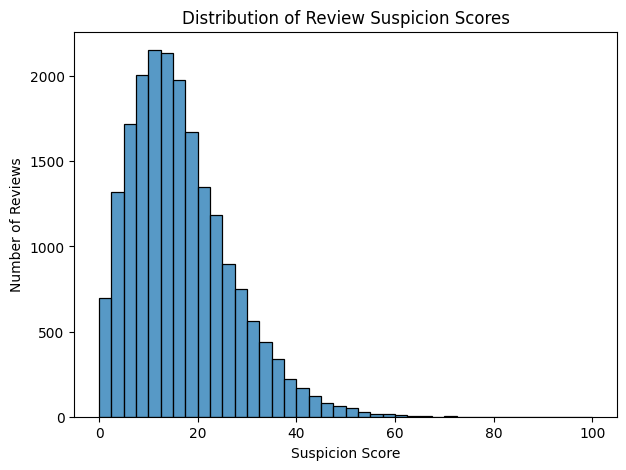

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))

sns.histplot(df['suspicion_score'], bins=40)

plt.title("Distribution of Review Suspicion Scores")
plt.xlabel("Suspicion Score")
plt.ylabel("Number of Reviews")

plt.show()

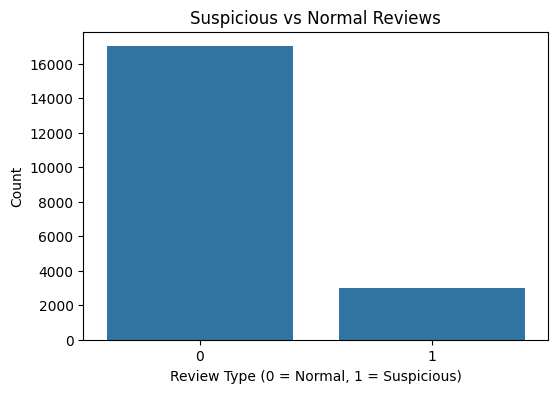

In [32]:
plt.figure(figsize=(6,4))

sns.countplot(x='suspicious', data=df)

plt.title("Suspicious vs Normal Reviews")
plt.xlabel("Review Type (0 = Normal, 1 = Suspicious)")
plt.ylabel("Count")

plt.show()

In [33]:
#Calculate the percentage of suspicious reviews
suspicious_percentage = df['suspicious'].mean() * 100

print("Suspicious reviews detected:", suspicious_percentage, "%")

Suspicious reviews detected: 15.0 %


In [34]:
with open("isolation_forest_yelp.pkl", "wb") as f:
    pickle.dump(iso_model, f)

with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)